In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('All libraries imported successfully!')

All libraries imported successfully!


In [75]:
df = pd.read_csv('D:\House Price Predictor\melb_data.csv')
df.shape

(13580, 21)

In [76]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.00,S,Biggin,3/12/2016,2.50,3067.00,2.00,1.00,1.00,202.00,NaN,NaN,Yarra,-37.80,145.00,Northern Metropolitan,4019.00
1,Abbotsford,25 Bloomburg St,2,h,1035000.00,S,Biggin,4/02/2016,2.50,3067.00,2.00,1.00,0.00,156.00,79.00,1900.00,Yarra,-37.81,144.99,Northern Metropolitan,4019.00
2,Abbotsford,5 Charles St,3,h,1465000.00,SP,Biggin,4/03/2017,2.50,3067.00,3.00,2.00,0.00,134.00,150.00,1900.00,Yarra,-37.81,144.99,Northern Metropolitan,4019.00
3,Abbotsford,40 Federation La,3,h,850000.00,PI,Biggin,4/03/2017,2.50,3067.00,3.00,2.00,1.00,94.00,NaN,NaN,Yarra,-37.80,145.00,Northern Metropolitan,4019.00
4,Abbotsford,55a Park St,4,h,1600000.00,VB,Nelson,4/06/2016,2.50,3067.00,3.00,1.00,2.00,120.00,142.00,2014.00,Yarra,-37.81,144.99,Northern Metropolitan,4019.00


In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 18  Longtitude     13

In [78]:
df.describe().round(2)

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.00,13580.00,13580.00,13580.00,13580.00,13580.00,13518.00,13580.00,7130.00,8205.00,13580.00,13580.00,13580.00
mean,2.94,1075684.08,10.14,3105.30,2.91,1.53,1.61,558.42,151.97,1964.68,-37.81,145.00,7454.42
std,0.96,639310.72,5.87,90.68,0.97,0.69,0.96,3990.67,541.01,37.27,0.08,0.10,4378.58
min,1.00,85000.00,0.00,3000.00,0.00,0.00,0.00,0.00,0.00,1196.00,-38.18,144.43,249.00
25%,2.00,650000.00,6.10,3044.00,2.00,1.00,1.00,177.00,93.00,1940.00,-37.86,144.93,4380.00
50%,3.00,903000.00,9.20,3084.00,3.00,1.00,2.00,440.00,126.00,1970.00,-37.80,145.00,6555.00
75%,3.00,1330000.00,13.00,3148.00,3.00,2.00,2.00,651.00,174.00,1999.00,-37.76,145.06,10331.00
max,10.00,9000000.00,48.10,3977.00,20.00,8.00,10.00,433014.00,44515.00,2018.00,-37.41,145.53,21650.00


In [79]:
df.describe(include='object')

,Suburb,Address,Type,Method,SellerG,Date,CouncilArea,Regionname
count,13580,13580,13580,13580,13580,13580,12211,13580
unique,314,13378,3,5,268,58,33,8
top,Reservoir,5 Charles St,h,S,Nelson,27/05/2017,Moreland,Southern Metropolitan
freq,359,3,9449,9022,1565,473,1163,4695


In [80]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing_df.to_string())

              Missing Count  Missing %
BuildingArea           6450      47.50
YearBuilt              5375      39.58
CouncilArea            1369      10.08
Car                      62       0.46


In [81]:
df_raw = df.copy()
print(f'Raw dataset shape: {df_raw.shape}')

Raw dataset shape: (13580, 21)


In [82]:
df = df.drop(columns=['Address'])

In [83]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['SaleYear']  = df['Date'].dt.year
df['SaleMonth'] = df['Date'].dt.month
df = df.drop(columns=['Date'])

print('Date parsed into SaleYear and SaleMonth')
print(df[['SaleYear', 'SaleMonth']].value_counts().head(10))

Date parsed into SaleYear and SaleMonth
SaleYear  SaleMonth
2017      7            1536
          5            1130
2016      11           1114
2017      6            1098
2016      9             925
2017      9             920
2016      5             899
2017      8             834
2016      6             732
          8             716
Name: count, dtype: int64


In [84]:
dupes = df.duplicated().sum()
print(f'Duplicate rows found: {dupes}')
if dupes > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found.')

Duplicate rows found: 13
Duplicates removed. New shape: (13567, 21)


In [85]:
cols_to_impute = ['Car', 'Landsize', 'BuildingArea', 'YearBuilt']

print('Missing values BEFORE imputation:')
print(df[cols_to_impute].isnull().sum())

for col in cols_to_impute:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f'  → {col}: filled with median = {median_val:.1f}')

print('\nMissing values AFTER imputation:')
print(df[cols_to_impute].isnull().sum())

Missing values BEFORE imputation:
Car               62
Landsize           0
BuildingArea    6445
YearBuilt       5371
dtype: int64
  → Car: filled with median = 2.0
  → Landsize: filled with median = 440.0
  → BuildingArea: filled with median = 126.0
  → YearBuilt: filled with median = 1970.0

Missing values AFTER imputation:
Car             0
Landsize        0
BuildingArea    0
YearBuilt       0
dtype: int64


In [86]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1          : ${Q1:,.0f}')
print(f'Q3          : ${Q3:,.0f}')
print(f'IQR         : ${IQR:,.0f}')
print(f'Lower bound : ${lower_bound:,.0f}')
print(f'Upper bound : ${upper_bound:,.0f}')

outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]
print(f'\nOutliers found: {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)')

df = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]
print(f'Outliers removed. Rows remaining: {len(df):,}')

Q1          : $650,000
Q3          : $1,330,000
IQR         : $680,000
Lower bound : $-370,000
Upper bound : $2,350,000

Outliers found: 612 (4.5%)
Outliers removed. Rows remaining: 12,955


In [87]:
cat_cols = ['Type', 'Method', 'Suburb', 'Regionname', 'CouncilArea', 'SellerG']

le = LabelEncoder()
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    print(f'{col} → {col}_enc  ({df[col].nunique()} unique values)')

Type → Type_enc  (3 unique values)
Method → Method_enc  (5 unique values)
Suburb → Suburb_enc  (314 unique values)
Regionname → Regionname_enc  (8 unique values)
CouncilArea → CouncilArea_enc  (33 unique values)
SellerG → SellerG_enc  (265 unique values)


In [88]:
print(f'  Raw rows      : {len(df_raw):,}')
print(f'  Clean rows    : {len(df):,}')
print(f'  Rows dropped  : {len(df_raw) - len(df):,}')
print(f'  Raw columns   : {df_raw.shape[1]}')
print(f'  Final columns : {df.shape[1]}')
print(f'  Remaining nulls: {df.isnull().sum().sum()}')

df.head()

  Raw rows      : 13,580
  Clean rows    : 12,955
  Rows dropped  : 625
  Raw columns   : 21
  Final columns : 27
  Remaining nulls: 1288


,Suburb,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,SaleYear,SaleMonth,Type_enc,Method_enc,Suburb_enc,Regionname_enc,CouncilArea_enc,SellerG_enc
0,Abbotsford,2,h,1480000.00,S,Biggin,2.50,3067.00,2.00,1.00,1.00,202.00,126.00,1970.00,Yarra,-37.80,145.00,Northern Metropolitan,4019.00,2016,12,0,1,0,2,31,23
1,Abbotsford,2,h,1035000.00,S,Biggin,2.50,3067.00,2.00,1.00,0.00,156.00,79.00,1900.00,Yarra,-37.81,144.99,Northern Metropolitan,4019.00,2016,2,0,1,0,2,31,23
2,Abbotsford,3,h,1465000.00,SP,Biggin,2.50,3067.00,3.00,2.00,0.00,134.00,150.00,1900.00,Yarra,-37.81,144.99,Northern Metropolitan,4019.00,2017,3,0,3,0,2,31,23
3,Abbotsford,3,h,850000.00,PI,Biggin,2.50,3067.00,3.00,2.00,1.00,94.00,126.00,1970.00,Yarra,-37.80,145.00,Northern Metropolitan,4019.00,2017,3,0,0,0,2,31,23
4,Abbotsford,4,h,1600000.00,VB,Nelson,2.50,3067.00,3.00,1.00,2.00,120.00,142.00,2014.00,Yarra,-37.81,144.99,Northern Metropolitan,4019.00,2016,6,0,4,0,2,31,153


In [89]:
df.to_csv('melb_clean.csv', index=False)
print('Clean dataset saved as melb_clean.csv')

Clean dataset saved as melb_clean.csv


In [90]:
df['PropertyAge'] = df['SaleYear'] - df['YearBuilt']

df['PropertyAge'] = df['PropertyAge'].clip(lower=0)

df['PricePerRoom'] = df['Price'] / df['Rooms']

df['PricePerSqm'] = df['Price'] / df['BuildingArea'].replace(0, np.nan)

df['TotalRooms'] = df['Rooms'] + df['Bathroom']

print('New features created:')
for feat in ['PropertyAge', 'PricePerRoom', 'PricePerSqm', 'TotalRooms']:
    print(f'   {feat}: min={df[feat].min():.0f}, max={df[feat].max():.0f}, mean={df[feat].mean():.0f}')

New features created:
   PropertyAge: min=0, max=821, mean=49
   PricePerRoom: min=32750, max=2115000, mean=351429
   PricePerSqm: min=30, max=1175000, mean=9496
   TotalRooms: min=1, max=16, mean=4


In [91]:
corr_cols = ['Price', 'Rooms', 'Distance', 'Bathroom', 'Car',
             'Landsize', 'BuildingArea', 'PropertyAge',
             'Propertycount', 'SaleMonth']

corr = df[corr_cols].corr()

print('\nTop correlations with Price:')
print(corr['Price'].sort_values(ascending=False).to_string())


Top correlations with Price:
Price            1.00
Rooms            0.49
Bathroom         0.38
PropertyAge      0.29
Car              0.20
BuildingArea     0.06
Landsize         0.04
SaleMonth        0.02
Propertycount   -0.06
Distance        -0.15


In [92]:
print(f"""
DATASET
  Clean rows    : {len(df):,}
  Total features: {df.shape[1]}

TARGET VARIABLE (Price)
  Min     : ${df['Price'].min():,.0f}
  Max     : ${df['Price'].max():,.0f}
  Mean    : ${df['Price'].mean():,.0f}
  Median  : ${df['Price'].median():,.0f}
  Skewness: {df['Price'].skew():.2f}

PROPERTY TYPE
  Houses     : {(df['Type']=='h').sum():,} ({(df['Type']=='h').mean()*100:.1f}%)
  Units      : {(df['Type']=='u').sum():,} ({(df['Type']=='u').mean()*100:.1f}%)
  Townhouses : {(df['Type']=='t').sum():,} ({(df['Type']=='t').mean()*100:.1f}%)

STRONGEST CORRELATIONS WITH PRICE
  Rooms        : {df['Rooms'].corr(df['Price']):.3f}
  Bathroom     : {df['Bathroom'].corr(df['Price']):.3f}
  BuildingArea : {df['BuildingArea'].corr(df['Price']):.3f}
  Distance     : {df['Distance'].corr(df['Price']):.3f}  (negative — expected)
  PropertyAge  : {df['PropertyAge'].corr(df['Price']):.3f}
""")
print('Ready for Feature Engineering & Model Training!')


DATASET
  Clean rows    : 12,955
  Total features: 31

TARGET VARIABLE (Price)
  Min     : $85,000
  Max     : $2,350,000
  Mean    : $982,641
  Median  : $880,000
  Skewness: 0.80

PROPERTY TYPE
  Houses     : 8,844 (68.3%)
  Units      : 3,010 (23.2%)
  Townhouses : 1,101 (8.5%)

STRONGEST CORRELATIONS WITH PRICE
  Rooms        : 0.486
  Bathroom     : 0.378
  BuildingArea : 0.056
  Distance     : -0.154  (negative — expected)
  PropertyAge  : 0.285

Ready for Feature Engineering & Model Training!


In [93]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor

df['PropertyAge'] = (df['SaleYear'] - df['YearBuilt']).clip(lower=0)
print(f"PropertyAge — min: {df['PropertyAge'].min():.0f}, max: {df['PropertyAge'].max():.0f}, mean: {df['PropertyAge'].mean():.1f}")

PropertyAge — min: 0, max: 821, mean: 49.1


In [94]:
df['TotalRooms'] = df['Rooms'] + df['Bathroom']
print('TotalRooms value counts:')
print(df['TotalRooms'].value_counts().sort_index().to_string())

TotalRooms value counts:
TotalRooms
1.00        1
2.00      692
3.00     3119
4.00     3723
5.00     2819
6.00     1714
7.00      594
8.00      215
9.00       47
10.00      22
11.00       4
12.00       3
13.00       1
16.00       1


In [95]:
df['RoomToBathroomRatio'] = df['Rooms'] / df['Bathroom'].replace(0, np.nan)
print(f"RoomToBathroomRatio — mean: {df['RoomToBathroomRatio'].mean():.2f}, median: {df['RoomToBathroomRatio'].median():.2f}")

RoomToBathroomRatio — mean: 2.11, median: 2.00


In [96]:
df['LandsizePerRoom'] = df['Landsize'] / df['Rooms'].replace(0, np.nan)
print(f"LandsizePerRoom — mean: {df['LandsizePerRoom'].mean():.1f}, median: {df['LandsizePerRoom'].median():.1f}")

LandsizePerRoom — mean: 191.5, median: 130.2


In [97]:
df['IsNewProperty'] = (df['PropertyAge'] <= 10).astype(int)
print(f"IsNewProperty — New: {df['IsNewProperty'].sum():,}  |  Old: {(df['IsNewProperty']==0).sum():,}")
print(f"Avg price — New: ${df[df['IsNewProperty']==1]['Price'].mean():,.0f}")
print(f"Avg price — Old: ${df[df['IsNewProperty']==0]['Price'].mean():,.0f}")

IsNewProperty — New: 1,191  |  Old: 11,764
Avg price — New: $843,781
Avg price — Old: $996,699


In [98]:
df['IsCloseToCBD'] = (df['Distance'] <= 10).astype(int)
print(f"IsCloseToCBD — Close: {df['IsCloseToCBD'].sum():,}  |  Far: {(df['IsCloseToCBD']==0).sum():,}")
print(f"Avg price — Close (<=10km): ${df[df['IsCloseToCBD']==1]['Price'].mean():,.0f}")
print(f"Avg price — Far   (>10km):  ${df[df['IsCloseToCBD']==0]['Price'].mean():,.0f}")

IsCloseToCBD — Close: 6,880  |  Far: 6,075
Avg price — Close (<=10km): $1,026,610
Avg price — Far   (>10km):  $932,846


In [99]:
df['HasParking'] = (df['Car'] > 0).astype(int)
print(f"HasParking — Yes: {df['HasParking'].sum():,}  |  No: {(df['HasParking']==0).sum():,}")
print(f"Avg price — Has Parking: ${df[df['HasParking']==1]['Price'].mean():,.0f}")
print(f"Avg price — No Parking:  ${df[df['HasParking']==0]['Price'].mean():,.0f}")

df['DistanceSquared'] = df['Distance'] ** 2
print(f"DistanceSquared — min: {df['DistanceSquared'].min():.1f}, max: {df['DistanceSquared'].max():.1f}")

HasParking — Yes: 11,958  |  No: 997
Avg price — Has Parking: $978,509
Avg price — No Parking:  $1,032,204
DistanceSquared — min: 0.0, max: 2313.6


In [100]:
new_features = ['PropertyAge', 'TotalRooms', 'RoomToBathroomRatio',
                'LandsizePerRoom', 'IsNewProperty', 'IsCloseToCBD',
                'HasParking', 'DistanceSquared']

print('New Features Summary')
print('='*50)
for f in new_features:
    print(f'  {f:<25}  nulls: {df[f].isnull().sum()}')
print(f'\nDataset shape: {df.shape}')

New Features Summary
  PropertyAge                nulls: 0
  TotalRooms                 nulls: 0
  RoomToBathroomRatio        nulls: 34
  LandsizePerRoom            nulls: 0
  IsNewProperty              nulls: 0
  IsCloseToCBD               nulls: 0
  HasParking                 nulls: 0
  DistanceSquared            nulls: 0

Dataset shape: (12955, 37)


In [101]:
exclude_from_skew = ['Price', 'Type_enc', 'Method_enc', 'Suburb_enc',
                     'Regionname_enc', 'CouncilArea_enc', 'SellerG_enc',
                     'IsNewProperty', 'IsCloseToCBD', 'HasParking',
                     'Postcode', 'SaleYear', 'SaleMonth', 'Bedroom2',
                     'PricePerRoom', 'PricePerSqm']

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
skew_cols    = [c for c in numeric_cols if c not in exclude_from_skew]
skewness     = df[skew_cols].skew().sort_values(ascending=False)

print('Feature Skewness:')
print('='*50)
for col, val in skewness.items():
    flag = 'HIGH' if abs(val) > 1 else 'OK'
    print(f'  {col:<28} {val:>8.3f}   {flag}')

Feature Skewness:
  BuildingArea                  106.138   HIGH
  Landsize                       29.911   HIGH
  LandsizePerRoom                21.986   HIGH
  DistanceSquared                 4.563   HIGH
  PropertyAge                     2.346   HIGH
  Distance                        1.655   HIGH
  Car                             1.367   HIGH
  Bathroom                        1.244   HIGH
  Propertycount                   1.080   HIGH
  TotalRooms                      0.711   OK
  RoomToBathroomRatio             0.576   OK
  Rooms                           0.376   OK
  Longtitude                     -0.176   OK
  Lattitude                      -0.465   OK
  YearBuilt                      -2.340   HIGH


In [102]:
high_skew      = skewness[abs(skewness) > 1].index.tolist()
log_transformed = []

for col in high_skew:
    if df[col].min() >= 0:
        df[col + '_log'] = np.log1p(df[col])
        log_transformed.append(col)
        new_skew = df[col + '_log'].skew()
        print(f'{col:<25} skew: {skewness[col]:>7.3f}  →  {new_skew:>7.3f}')

print(f'\nTransformed {len(log_transformed)} features.')

BuildingArea              skew: 106.138  →   -3.125
Landsize                  skew:  29.911  →   -1.597
LandsizePerRoom           skew:  21.986  →   -1.421
DistanceSquared           skew:   4.563  →   -0.468
PropertyAge               skew:   2.346  →   -1.630
Distance                  skew:   1.655  →   -0.357
Car                       skew:   1.367  →   -0.436
Bathroom                  skew:   1.244  →    0.582
Propertycount             skew:   1.080  →   -0.668
YearBuilt                 skew:  -2.340  →   -3.742

Transformed 10 features.


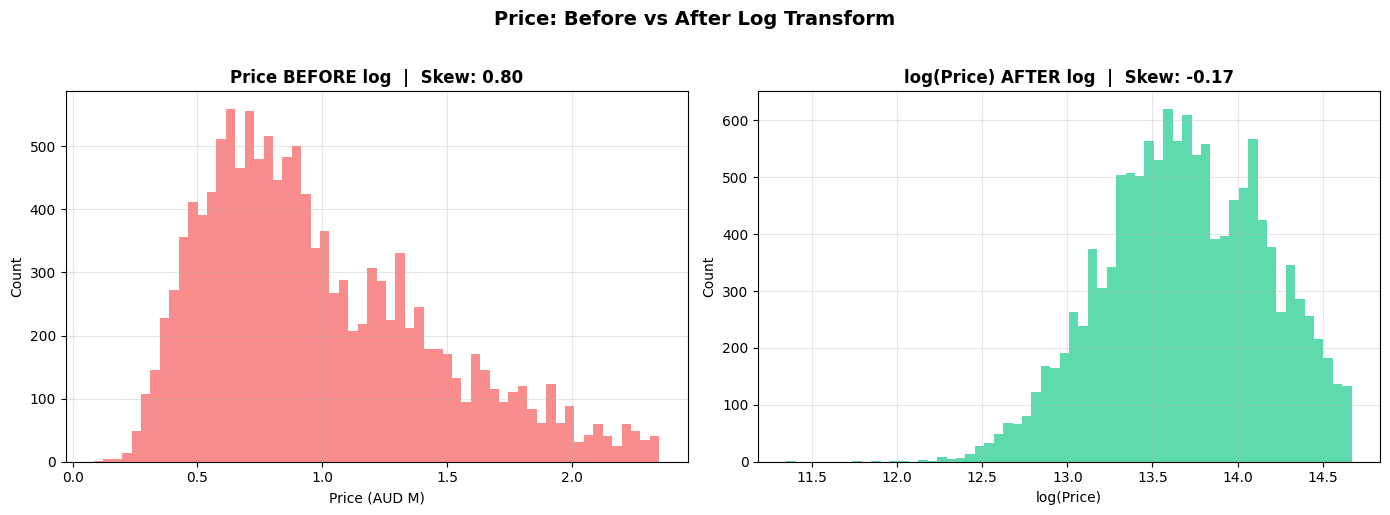

In [103]:
df['Price_log'] = np.log1p(df['Price'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Price'] / 1e6, bins=60, color='#F87171', alpha=0.8, edgecolor='none')
axes[0].set_title(f"Price BEFORE log  |  Skew: {df['Price'].skew():.2f}",
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price (AUD M)'); axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['Price_log'], bins=60, color='#34D399', alpha=0.8, edgecolor='none')
axes[1].set_title(f"log(Price) AFTER log  |  Skew: {df['Price_log'].skew():.2f}",
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(Price)'); axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Price: Before vs After Log Transform', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [104]:
ohe_cols = [c for c in ['Type', 'Method'] if c in df.columns]

if ohe_cols:
    print('Applying One-Hot Encoding to:', ohe_cols)
    df = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)
    new_ohe = [c for c in df.columns if any(c.startswith(f'{col}_') for col in ['Type', 'Method'])]
    print(f'New columns created: {new_ohe}')
else:
    print('One-hot columns already encoded from Step 4, skipping.')

print(f'Dataset shape: {df.shape}')

Applying One-Hot Encoding to: ['Type', 'Method']
New columns created: ['Type_enc', 'Method_enc', 'Type_t', 'Type_u', 'Method_S', 'Method_SA', 'Method_SP', 'Method_VB']
Dataset shape: (12955, 52)


In [105]:
label_cols = ['Suburb', 'Regionname', 'CouncilArea', 'SellerG']
le = LabelEncoder()

for col in label_cols:
    enc_col = col + '_enc'
    if col in df.columns and enc_col not in df.columns:
        df[enc_col] = le.fit_transform(df[col].astype(str))
        print(f'  ✅ {col} → {enc_col}  ({df[col].nunique()} unique values)')
    else:
        print(f'  ⏭  {col}_enc already exists, skipping.')

print(f'\nFinal dataset shape: {df.shape}')

  ⏭  Suburb_enc already exists, skipping.
  ⏭  Regionname_enc already exists, skipping.
  ⏭  CouncilArea_enc already exists, skipping.
  ⏭  SellerG_enc already exists, skipping.

Final dataset shape: (12955, 52)


In [106]:
base_features = [
    'Rooms', 'Distance', 'Bathroom', 'Car',
    'Propertycount', 'SaleYear', 'SaleMonth',
    'PropertyAge', 'TotalRooms', 'RoomToBathroomRatio',
    'IsNewProperty', 'IsCloseToCBD', 'HasParking', 'DistanceSquared',
    'Suburb_enc', 'Regionname_enc', 'CouncilArea_enc', 'SellerG_enc',
]

log_feats = [c + '_log' for c in log_transformed if c + '_log' in df.columns]

ohe_feats = [c for c in df.columns if c.startswith('Type_') or c.startswith('Method_')]

all_features = base_features + log_feats + ohe_feats

final_features = [f for f in all_features if f in df.columns]

print(f'Total features for model: {len(final_features)}')
for f in final_features:
    print(f'   {f}')

Total features for model: 36
   Rooms
   Distance
   Bathroom
   Car
   Propertycount
   SaleYear
   SaleMonth
   PropertyAge
   TotalRooms
   RoomToBathroomRatio
   IsNewProperty
   IsCloseToCBD
   HasParking
   DistanceSquared
   Suburb_enc
   Regionname_enc
   CouncilArea_enc
   SellerG_enc
   BuildingArea_log
   Landsize_log
   LandsizePerRoom_log
   DistanceSquared_log
   PropertyAge_log
   Distance_log
   Car_log
   Bathroom_log
   Propertycount_log
   YearBuilt_log
   Type_enc
   Method_enc
   Type_t
   Type_u
   Method_S
   Method_SA
   Method_SP
   Method_VB


In [107]:
X_raw = df[final_features].fillna(df[final_features].median())
y     = df['Price_log']

scaler    = StandardScaler()
X_scaled  = pd.DataFrame(scaler.fit_transform(X_raw), columns=final_features)

print(f'X shape : {X_scaled.shape}')
print(f'y shape : {y.shape}')
print(f'Nulls in X: {X_scaled.isnull().sum().sum()}')
print(f'Nulls in y: {y.isnull().sum()}')
print('\nSample after scaling (mean should be ~0, std ~1):')
print(X_scaled[['Rooms', 'Distance', 'PropertyAge']].agg(['mean', 'std']).round(4))

X shape : (12955, 36)
y shape : (12955,)
Nulls in X: 0
Nulls in y: 0

Sample after scaling (mean should be ~0, std ~1):
      Rooms  Distance  PropertyAge
mean   0.00     -0.00         0.00
std    1.00      1.00         1.00


In [108]:
rf_selector = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
rf_selector.fit(X_scaled, y)

importances = pd.Series(
    rf_selector.feature_importances_, index=final_features
).sort_values(ascending=False)

print('Feature Importances (Random Forest):')
print('='*55)
for col, val in importances.items():
    bar  = '█' * int(val * 300)
    flag = '✅' if val >= 0.01 else '❌ low'
    print(f'  {col:<30} {val:.4f}  {bar[:25]}  {flag}')

Feature Importances (Random Forest):
  Type_enc                       0.1832  █████████████████████████  ✅
  Regionname_enc                 0.1817  █████████████████████████  ✅
  Type_u                         0.1815  █████████████████████████  ✅
  TotalRooms                     0.0878  █████████████████████████  ✅
  Rooms                          0.0569  █████████████████  ✅
  Landsize_log                   0.0536  ████████████████  ✅
  Distance_log                   0.0404  ████████████  ✅
  DistanceSquared                0.0400  ███████████  ✅
  DistanceSquared_log            0.0320  █████████  ✅
  Distance                       0.0304  █████████  ✅
  CouncilArea_enc                0.0277  ████████  ✅
  BuildingArea_log               0.0202  ██████  ✅
  Type_t                         0.0106  ███  ✅
  Propertycount                  0.0070  ██  ❌ low
  Propertycount_log              0.0070  ██  ❌ low
  Suburb_enc                     0.0058  █  ❌ low
  PropertyAge_log                0.

In [109]:
selected_features = importances[importances >= 0.01].index.tolist()

domain_flags = ['IsNewProperty', 'IsCloseToCBD', 'HasParking']
for f in domain_flags:
    if f in final_features and f not in selected_features:
        selected_features.append(f)

X = df[selected_features].fillna(df[selected_features].median())
y = df['Price_log']

print(f'Features after selection: {len(selected_features)} (was {len(final_features)})')
print('\nSelected features:')
for f in selected_features:
    print(f'{f}')

Features after selection: 16 (was 36)

Selected features:
Type_enc
Regionname_enc
Type_u
TotalRooms
Rooms
Landsize_log
Distance_log
DistanceSquared
DistanceSquared_log
Distance
CouncilArea_enc
BuildingArea_log
Type_t
IsNewProperty
IsCloseToCBD
HasParking


In [110]:
df.to_csv('melb_engineered.csv', index=False)
X.to_csv('melb_X.csv', index=False)
y.to_csv('melb_y.csv', index=False, header=True)

print('Saved:')
print('   melb_engineered.csv — full dataset with all new features')
print('   melb_X.csv          — final feature matrix X')
print('   melb_y.csv          — target variable log(Price)')
print(f'\nX shape: {X.shape}   |   y shape: {y.shape}')

Saved:
   melb_engineered.csv — full dataset with all new features
   melb_X.csv          — final feature matrix X
   melb_y.csv          — target variable log(Price)

X shape: (12955, 16)   |   y shape: (12955,)


In [111]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set  : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set      : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Features used : {X_train.shape[1]}')

Training set  : 10,364 rows  (80%)
Test set      : 2,591 rows  (20%)
Features used : 16


In [112]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [113]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

In [114]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train_scaled, y_train)
gb_pred = gb.predict(X_test_scaled)


In [115]:
def evaluate_model(name, y_true, y_pred):

    r2   = r2_score(y_true, y_pred)
    price_true = np.expm1(y_true)
    price_pred = np.expm1(y_pred)
    mae  = mean_absolute_error(price_true, price_pred)
    rmse = np.sqrt(mean_squared_error(price_true, price_pred))
    return {'Model': name, 'R²': r2, 'MAE': mae, 'RMSE': rmse,
            'y_pred': y_pred}

results = [
    evaluate_model('Linear Regression',  y_test, lr_pred),
    evaluate_model('Random Forest',       y_test, rf_pred),
    evaluate_model('Gradient Boosting',   y_test, gb_pred),
]

print('='*60)
print(f'  {"Model":<25}  {"R²":>7}   {"MAE (AUD)":>12}   {"RMSE (AUD)":>12}')
print('='*60)
for r in results:
    best = ' ⭐' if r['R²'] == max(x['R²'] for x in results) else ''
    print(f'  {r["Model"]:<25}  {r["R²"]:>7.4f}   ${r["MAE"]:>11,.0f}   ${r["RMSE"]:>11,.0f}{best}')
print('='*60)

  Model                           R²      MAE (AUD)     RMSE (AUD)
  Linear Regression           0.5482   $    252,381   $    338,117
  Random Forest               0.8321   $    149,082   $    208,543
  Gradient Boosting           0.8370   $    149,537   $    209,478 ⭐


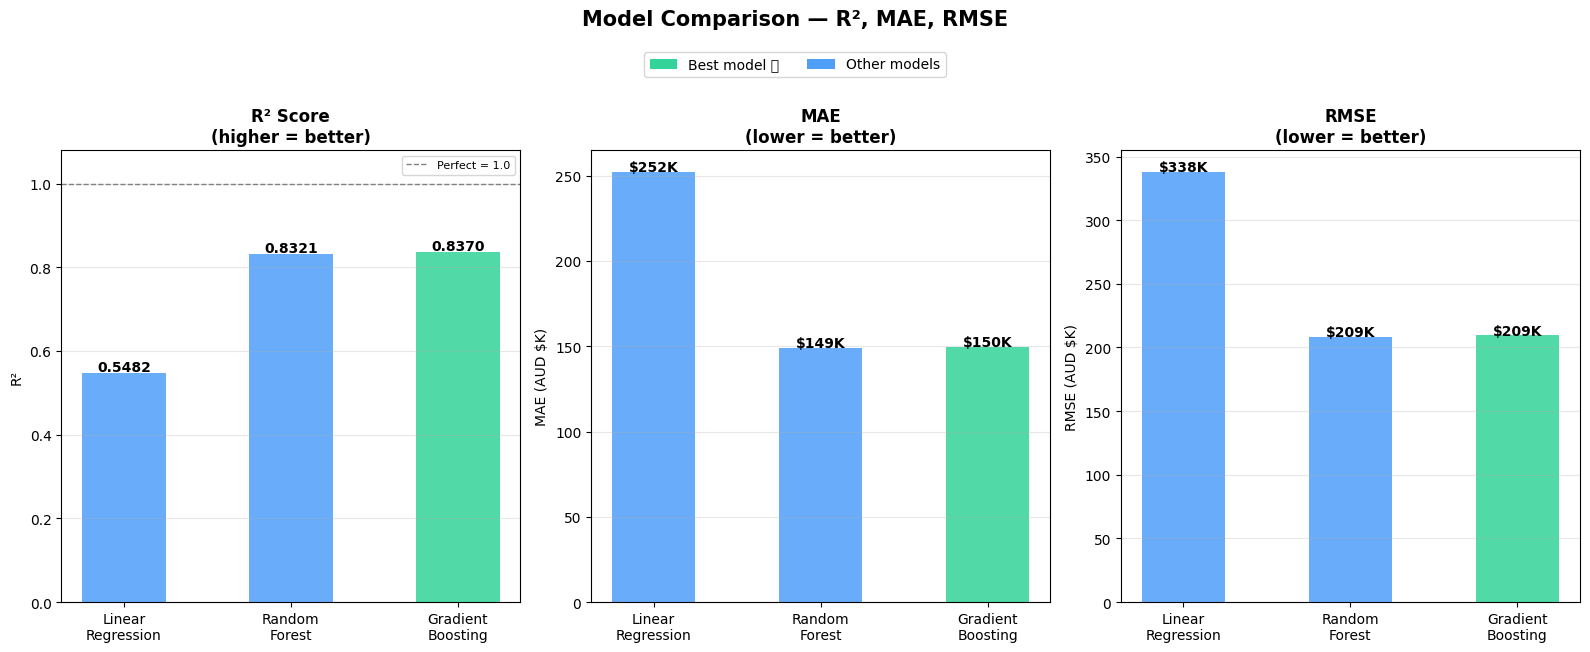

In [116]:
model_names  = [r['Model'] for r in results]
short_names  = ['Linear\nRegression', 'Random\nForest', 'Gradient\nBoosting']
r2_vals      = [r['R²']   for r in results]
mae_vals     = [r['MAE']  for r in results]
rmse_vals    = [r['RMSE'] for r in results]
best_idx     = r2_vals.index(max(r2_vals))
bar_colors   = ['#34D399' if i == best_idx else '#4F9EF8'
                for i in range(len(results))]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# R²
bars = axes[0].bar(short_names, r2_vals, color=bar_colors, alpha=0.85, width=0.5)
for bar, v in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.005,
                 f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, 1.08)
axes[0].axhline(1.0, color='gray', lw=1, ls='--', label='Perfect = 1.0')
axes[0].set_title('R² Score\n(higher = better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R²'); axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3, axis='y')

# MAE
bars = axes[1].bar(short_names, [v/1000 for v in mae_vals], color=bar_colors, alpha=0.85, width=0.5)
for bar, v in zip(bars, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, v/1000 + 0.5,
                 f'${v/1000:.0f}K', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('MAE\n(lower = better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE (AUD $K)'); axes[1].grid(True, alpha=0.3, axis='y')

# RMSE
bars = axes[2].bar(short_names, [v/1000 for v in rmse_vals], color=bar_colors, alpha=0.85, width=0.5)
for bar, v in zip(bars, rmse_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, v/1000 + 0.5,
                 f'${v/1000:.0f}K', ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('RMSE\n(lower = better)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('RMSE (AUD $K)'); axes[2].grid(True, alpha=0.3, axis='y')

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(facecolor='#34D399', label='Best model ⭐'),
    Patch(facecolor='#4F9EF8', label='Other models'),
], loc='upper center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 1.02))

plt.suptitle('Model Comparison — R², MAE, RMSE', fontsize=15, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()

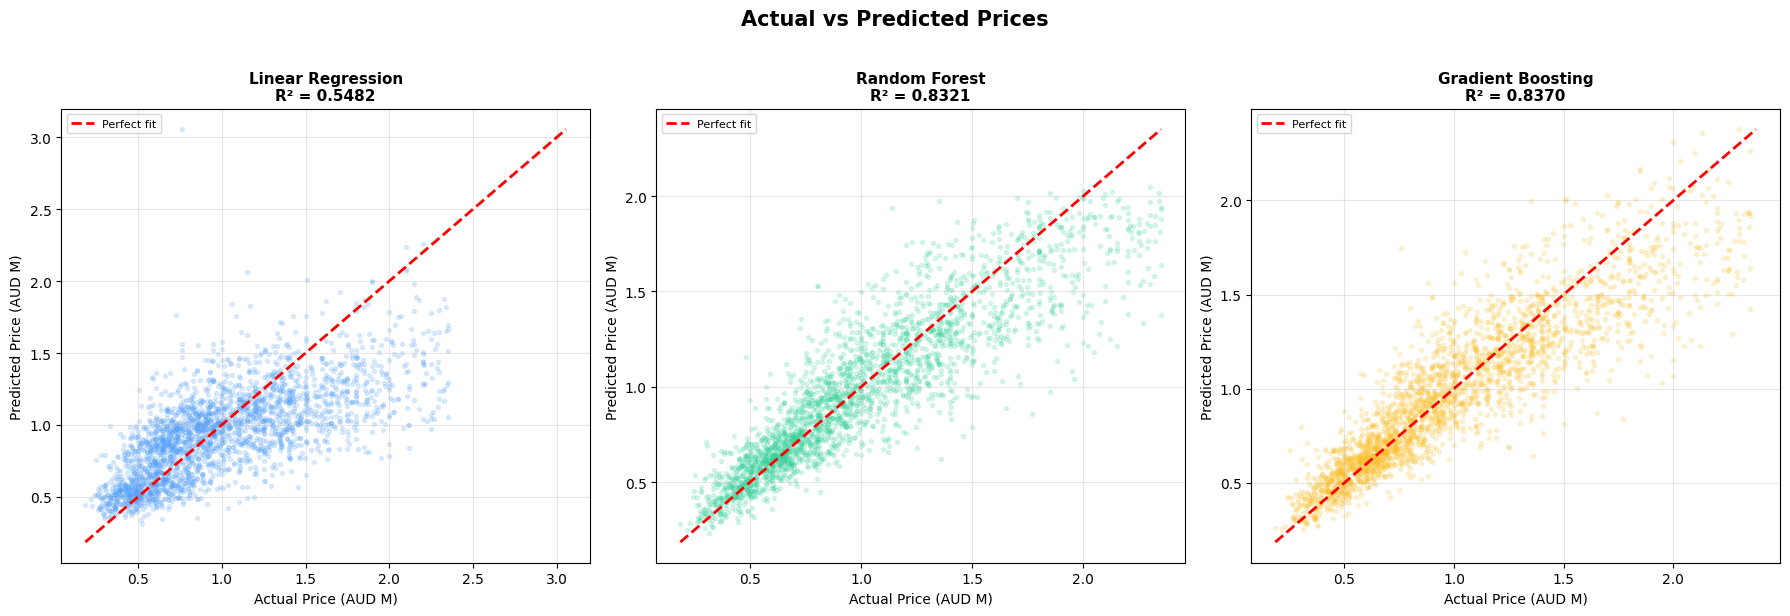

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

price_actual = np.expm1(y_test.values)

for ax, r, color in zip(axes, results, ['#4F9EF8', '#34D399', '#FBBF24']):
    price_pred = np.expm1(r['y_pred'])
    ax.scatter(price_actual / 1e6, price_pred / 1e6,
               alpha=0.18, s=8, color=color)
    mn = min(price_actual.min(), price_pred.min()) / 1e6
    mx = max(price_actual.max(), price_pred.max()) / 1e6
    ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect fit')
    ax.set_title(f"{r['Model']}\nR² = {r['R²']:.4f}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual Price (AUD M)')
    ax.set_ylabel('Predicted Price (AUD M)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted Prices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [118]:
best_result = max(results, key=lambda r: r['R²'])
best_model_obj = {'Linear Regression': lr,
                   'Random Forest': rf,
                   'Gradient Boosting': gb}[best_result['Model']]

cv_scores = cross_val_score(
    best_model_obj, X_train_scaled, y_train,
    cv=5, scoring='r2', n_jobs=-1
)

print(f'5-Fold Cross-Validation — {best_result["Model"]}')
print('='*50)
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: R² = {score:.4f}')
print(f'\n  Mean R²  : {cv_scores.mean():.4f}')
print(f'  Std Dev  : {cv_scores.std():.4f}')
print(f'  Test R²  : {best_result["R²"]:.4f}   ← should be close to mean')

5-Fold Cross-Validation — Gradient Boosting
  Fold 1: R² = 0.8201
  Fold 2: R² = 0.8318
  Fold 3: R² = 0.8320
  Fold 4: R² = 0.8309
  Fold 5: R² = 0.8363

  Mean R²  : 0.8302
  Std Dev  : 0.0054
  Test R²  : 0.8370   ← should be close to mean


In [119]:
best = max(results, key=lambda r: r['R²'])

for r in results:
    star = ' ⭐ BEST' if r['Model'] == best['Model'] else ''
    print(f"  {r['Model']:<25}  R²={r['R²']:.4f}  MAE=${r['MAE']:,.0f}  RMSE=${r['RMSE']:,.0f}{star}")

print(f"""
BEST MODEL  : {best['Model']}
  R²        : {best['R²']:.4f}  (explains {best['R²']*100:.1f}% of price variance)
  MAE       : ${best['MAE']:,.0f}  (avg prediction error per house)
  RMSE      : ${best['RMSE']:,.0f}
""")

  Linear Regression          R²=0.5482  MAE=$252,381  RMSE=$338,117
  Random Forest              R²=0.8321  MAE=$149,082  RMSE=$208,543
  Gradient Boosting          R²=0.8370  MAE=$149,537  RMSE=$209,478 ⭐ BEST

BEST MODEL  : Gradient Boosting
  R²        : 0.8370  (explains 83.7% of price variance)
  MAE       : $149,537  (avg prediction error per house)
  RMSE      : $209,478



In [120]:
import joblib

joblib.dump(best_model_obj,    'model.pkl')
joblib.dump(scaler,            'scaler.pkl')
joblib.dump(selected_features, 'features.pkl')
best_model_name = max(results, key=lambda r: r['R²'])['Model']
print('Saved to disk:')
print(f'   model.pkl     → {best_model_name}')
print(f'   scaler.pkl    → StandardScaler (fit on {X_train.shape[0]:,} training rows)')
print(f'   features.pkl  → {len(selected_features)} features in correct order')
print()
print('To reload later:')
print("   model    = joblib.load('model.pkl')")
print("   scaler   = joblib.load('scaler.pkl')")
print("   features = joblib.load('features.pkl')")

Saved to disk:
   model.pkl     → Gradient Boosting
   scaler.pkl    → StandardScaler (fit on 10,364 training rows)
   features.pkl  → 16 features in correct order

To reload later:
   model    = joblib.load('model.pkl')
   scaler   = joblib.load('scaler.pkl')
   features = joblib.load('features.pkl')


In [121]:
model_loaded    = joblib.load('model.pkl')
scaler_loaded   = joblib.load('scaler.pkl')
features_loaded = joblib.load('features.pkl')

sample_X        = X_test.iloc[:5][features_loaded].fillna(0)
orig_preds      = np.expm1(best_model_obj.predict(scaler.transform(X_test.iloc[:5][selected_features].fillna(0))))
loaded_preds    = np.expm1(model_loaded.predict(scaler_loaded.transform(sample_X)))

print('Verification — Original vs Reloaded Model:')
print('='*55)
for orig, loaded in zip(orig_preds, loaded_preds):
    match = '✅ Match' if abs(orig - loaded) < 1 else '❌ Mismatch'
    print(f'  Original: ${orig:>12,.0f}   Loaded: ${loaded:>12,.0f}   {match}')

Verification — Original vs Reloaded Model:
  Original: $     501,947   Loaded: $     501,947   ✅ Match
  Original: $   1,209,477   Loaded: $   1,209,477   ✅ Match
  Original: $   1,067,078   Loaded: $   1,067,078   ✅ Match
  Original: $     381,796   Loaded: $     381,796   ✅ Match
  Original: $   1,938,943   Loaded: $   1,938,943   ✅ Match


In [122]:
print("Selected features:")
for f in selected_features:
    print(f"  {f}")

Selected features:
  Type_enc
  Regionname_enc
  Type_u
  TotalRooms
  Rooms
  Landsize_log
  Distance_log
  DistanceSquared
  DistanceSquared_log
  Distance
  CouncilArea_enc
  BuildingArea_log
  Type_t
  IsNewProperty
  IsCloseToCBD
  HasParking
